In [15]:
import pandas as pd
import matplotlib.pyplot as plt
# from scipy.signal import find_peaks
import numpy as np
import pymc as pm
from scipy.optimize import curve_fit
#from scipy.stats import t
#from matplotlib.ticker import MultipleLocator
#import matplotlib.cm as cm
#from scipy.optimize import minimize

In [2]:
file_path = "csv-files/zro2_white&green_ 50_days.csv"
data_50 = pd.read_csv(file_path, header=None)
file_path2 = "csv-files/new_data.csv"
data_30 = pd.read_csv(file_path2, header=None)

spectrum_50 = data_50[0].values
spectrum_30 = data_30[0].values


t_50 = 4279386 # 50 days exposure
t_30 = 2827661 # 50 days exposure

t_tot = t_50 + t_30



In [3]:
a_50 = 0.357304
b_50 = -0.295444
c_50  = 1.352297E-009
E_kev_50 =  np.arange(len(spectrum_50)) * a_50 + b_50 + c_50 * np.arange(len(spectrum_50))**2
mask = (E_kev_50>=0) & (E_kev_50 <= 3000)
E_kev_50 = E_kev_50[mask]
spectrum_50 = spectrum_50[mask]
spectrum_50_norm = spectrum_50/t_50

In [4]:
b_30 = 2.78
a_30 = 0.4142675
c_30  = 8.4771*1e-7
E_kev_30 =  np.arange(len(spectrum_30)) * a_30 + b_30 + c_30 * np.arange(len(spectrum_30))**2
mask = (E_kev_30>=0) & (E_kev_30 <= 3000)
E_kev_30 = E_kev_30[mask]
spectrum_30 = spectrum_30[mask]
spectrum_30_norm = spectrum_30/t_30

In [5]:
bins_common = np.arange(0,3000,1.26)
bins_common = np.arange(0,3000,0.4)

N50, bin_edge50 = np.histogram(E_kev_50, bins = bins_common, weights = spectrum_50  )

N30, bin_edge30 = np.histogram(E_kev_30, bins = bins_common, weights = spectrum_30)



In [6]:
E_tot = (bin_edge50[1:] + bin_edge50[:-1])/2

Ntot = N50 + N30

# energy resolution

In [7]:
def sigma_fun(E):
    A = 3.68436e1
    B = 1.72714e4
    return (E * np.sqrt(A/E + B/E**2)) / 2.355/100

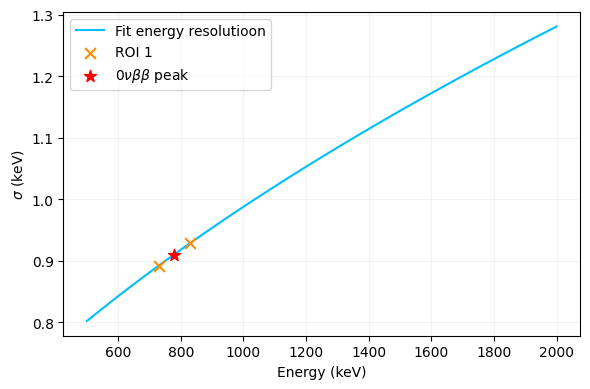

In [8]:
e = np.linspace(500, 2000, 50)
# ROI 1
plt.figure(figsize = (6,4))
plt.plot(e, sigma_fun(e), color = 'deepskyblue', label = "Fit energy resolutioon")

plt.scatter([730, 830], [sigma_fun(730), sigma_fun(830)], marker = "x", s = 60, color="darkorange",  zorder=10, label = "ROI 1"  )
plt.scatter([778], [sigma_fun(778)], marker = "*", s = 80, color="red",  zorder=10, label = r"0$\nu\beta\beta$ peak"  )


plt.xlabel("Energy (keV)")
plt.ylabel(rf"$\sigma$ (keV)")
plt.legend()
plt.grid(alpha=0.15)
plt.tight_layout()
plt.show()

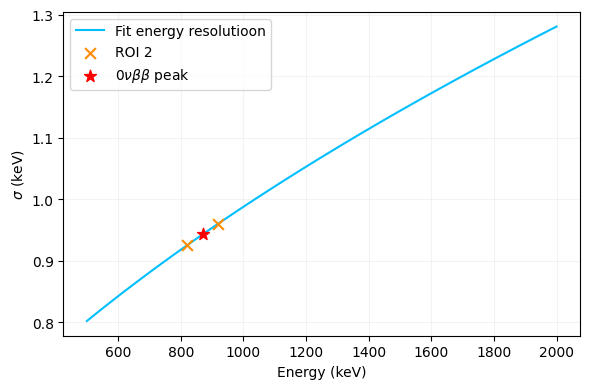

In [9]:
e = np.linspace(500, 2000, 50)
# ROI 2
plt.figure(figsize = (6,4))
plt.plot(e, sigma_fun(e), color = 'deepskyblue', label = "Fit energy resolutioon")

plt.scatter([820, 920], [sigma_fun(820), sigma_fun(920)], marker = "x", s = 60, color="darkorange",  zorder=10, label = "ROI 2"  )
plt.scatter([871], [sigma_fun(871)], marker = "*", s = 80, color="red",  zorder=10, label = r"0$\nu\beta\beta$ peak"  )


plt.xlabel("Energy (keV)")
plt.ylabel(rf"$\sigma$ (keV)")
plt.legend()
plt.grid(alpha=0.15)
plt.tight_layout()
plt.show()

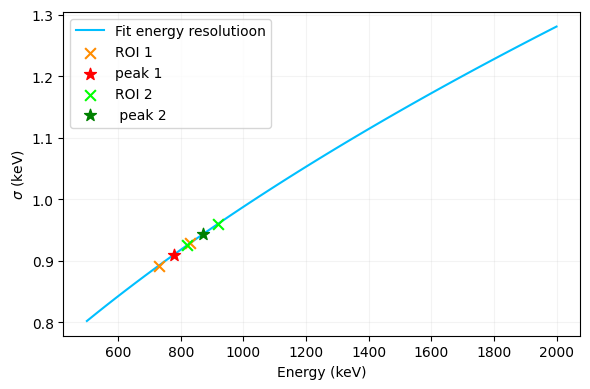

In [10]:
e = np.linspace(500, 2000, 50)
# ROI 1
plt.figure(figsize = (6,4))
plt.plot(e, sigma_fun(e), color = 'deepskyblue', label = "Fit energy resolutioon")

plt.scatter([730, 830], [sigma_fun(730), sigma_fun(830)], marker = "x", s = 60, color="darkorange",  zorder=10, label = "ROI 1"  )
plt.scatter([778], [sigma_fun(778)], marker = "*", s = 80, color="red",  zorder=10, label = r"peak 1"  )

plt.scatter([820, 920], [sigma_fun(820), sigma_fun(920)], marker = "x", s = 60, color="lime",  zorder=10, label = "ROI 2"  )
plt.scatter([871], [sigma_fun(871)], marker = "*", s = 80, color="green",  zorder=10, label = r" peak 2"  )


plt.xlabel("Energy (keV)")
plt.ylabel(rf"$\sigma$ (keV)")
plt.legend()
plt.grid(alpha=0.15)
plt.tight_layout()
plt.show()

# Prior determination fit

In [20]:
def gaussian_base(E, mu, sigma, A, B):
    G = A / (sigma  * np.sqrt( 2 * np.pi)) * np.exp( - 1/2 * ((E-mu)/sigma)**2 )
    return G + B

In [21]:
peak = 897.77
de = 10

mask_roi = (E_tot>peak -de) & (E_tot < peak+de)
ROI = E_tot[mask_roi]
NROI = Ntot[mask_roi]

p0 = [peak, sigma_fun(peak), sum(NROI), 0 ]

popt, pcov = curve_fit(gaussian_base, ROI, NROI, p0 = p0)


In [22]:
popt

array([897.56528749,   0.97185646,  44.08756414,   1.39562179])

In [46]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit


def gaussian_base(E, mu, sigma, A, B):
    return A / (sigma * np.sqrt(2 * np.pi)) * np.exp(-0.5 * ((E - mu) / sigma)**2) + B


def fit_gaussian_curvefit_plot(E, N, center, de=4, ax=None):
    """
    Fit gaussiano con curve_fit + plot.
    Restituisce:
        fit_val = [A, mu, sigma, B]
        fit_err = errori simmetrici
        fig = figura del plot
    """

    # --- ROI ---
    mask = (E > center - de) & (E < center + de)
    ROI = E[mask]
    NROI = N[mask]

    # --- initial guess ---
    p0 = [
        center,            # mu
        (center * 0.001),  # sigma ~ 0.1% dell'energia (o usa sigma_fun)
        np.sum(NROI),      # A (area)
        0                  # B
    ]

    # --- fit ---
    popt, pcov = curve_fit(gaussian_base, ROI, NROI, p0=p0 )
    perr = np.sqrt(np.diag(pcov))

    mu_fit, sigma_fit, A_fit, B_fit = popt
    err_mu, err_sigma, err_A, err_B = perr

    # --- Plot ---
    fig, ax = plt.subplots(2, 1, figsize=(7, 6), sharex=True,
                           gridspec_kw={"height_ratios": [3, 1]})

    # Fit curve
    E_fit = np.linspace(ROI.min(), ROI.max(), 400)
    N_fit = gaussian_base(E_fit, *popt)

    # --- Top panel: data + fit ---
    #ax[0].scatter(ROI, NROI, s=12, color="black", label="Dati")
    ax[0].step(ROI, NROI, where="mid", color="black", label="Dati")

    
    ax[0].plot(E_fit, N_fit, color="red", lw=2, label="Fit Gaussiano")

    ax[0].set_ylabel("Conteggi")
    ax[0].legend()
    ax[0].grid(alpha=0.3)

    # --- Bottom panel: residui ---
    residuals = NROI - gaussian_base(ROI, *popt)
    ax[1].scatter(ROI, residuals, s=12, color="blue")
    ax[1].axhline(0, color="red", lw=1)
    ax[1].set_xlabel("Energia [keV]")
    ax[1].set_ylabel("Residui")
    ax[1].grid(alpha=0.3)

    fig.tight_layout()

    # --- output coerente con la tua funzione Poisson ---
    fit_val = np.array([A_fit, mu_fit, sigma_fit, B_fit])
    fit_err = np.array([err_A, err_mu, err_sigma, err_B])

    return fit_val, fit_err, fig


{'N': np.float64(40.67089396539792), 'err_N': np.float64(4.919362591769384), 'mu': np.float64(897.5694128250177), 'sigma': np.float64(0.9196570356578894), 'B': np.float64(2.066198356997263)}


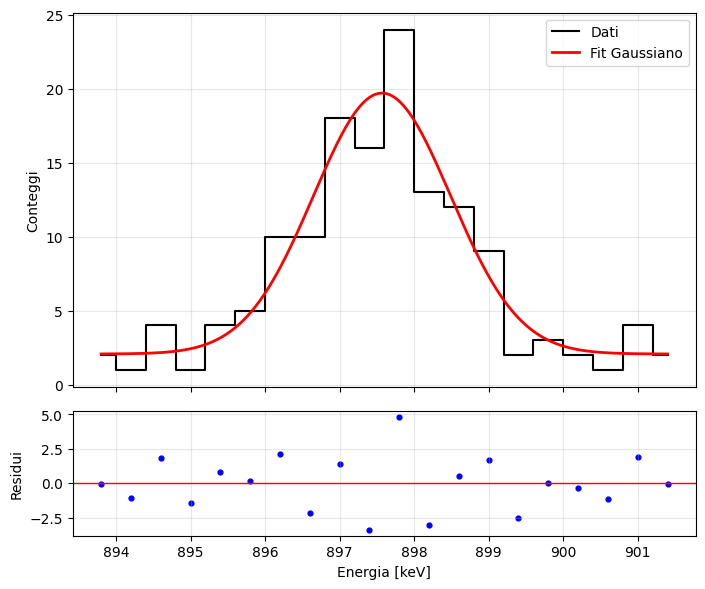

{'N': np.float64(22.706692960331154), 'err_N': np.float64(4.504338579843315), 'mu': np.float64(910.472032275663), 'sigma': np.float64(0.9825895031490957), 'B': np.float64(1.1117870185326648)}


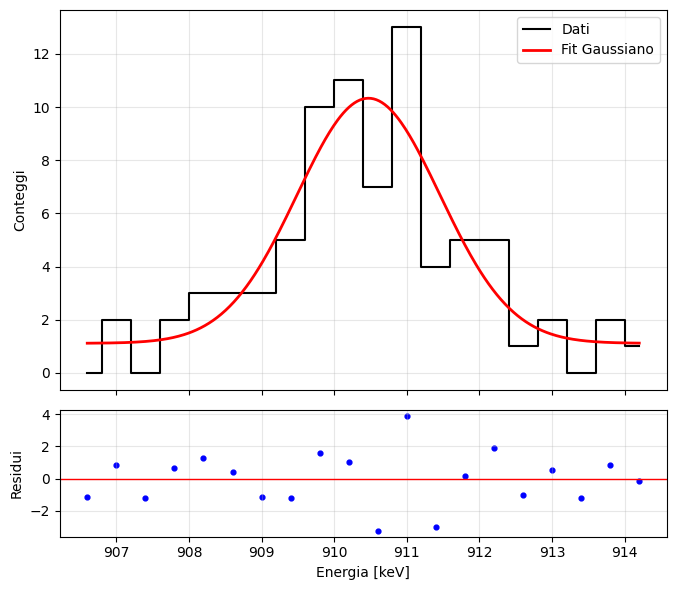

In [49]:
results = {}
picchi_bg = ["207Tl", "228Ac"]
peaks = [897.77, 910.204]
de_arr = [4, 4]

for name, peak, de in zip(picchi_bg, peaks, de_arr):

    fit_val, fit_err, fig = fit_gaussian_curvefit_plot(
        E_tot, Ntot, center=peak, de=de
    )

    A_fit, mu_fit, sigma_fit, B_fit = fit_val
    err_A, err_mu, err_sigma, err_B = fit_err

    results[name] = {
        "N": A_fit,
        "err_N": err_A,
        "mu": mu_fit,
        "sigma": sigma_fit,
        "B": B_fit
    }

    print(results[name])

    # Se vuoi mostrare il plot:
    plt.show()


def fit_gaussian_poisson_plot(E, N, center, de, nscan=80, make_plots=True):
    """
    Fit gaussiana + fondo costante con likelihood Poissoniana.

    Miglioramenti rispetto alla versione originale:
    - niente histogram inutile
    - vettorizzazione completa
    - meno allocazioni
    - profiling più veloce
    - Hessian error estimate immediato
    - profile likelihood opzionale
    - plotting più leggero

    Parametri
    ----------
    E : array
        Ascisse / energie
    N : array
        Conteggi
    center : float
        Centro ROI
    de : float
        Half-width ROI
    nscan : int
        Numero punti profile likelihood
    make_plots : bool
        Produce grafici

    Returns
    -------
    fit_values
    err_minus_all
    err_plus_all
    result
    """

    import numpy as np
    import matplotlib.pyplot as plt
    from scipy.optimize import minimize

    # =========================================================
    # ARRAY
    # =========================================================
    E = np.asarray(E, dtype=np.float64)
    N = np.asarray(N, dtype=np.float64)

    # =========================================================
    # ROI
    # =========================================================
    roi_min = center - de
    roi_max = center + de

    mask = (E >= roi_min) & (E <= roi_max)

    x = E[mask]
    y = N[mask]

    # =========================================================
    # MODELLO
    # =========================================================
    SQRT2PI = np.sqrt(2.0 * np.pi)

    def model(params):
        A, mu, sigma, B = params

        z = (x - mu) / sigma

        return (
            A * np.exp(-0.5 * z * z) / (sigma * SQRT2PI)
            + B
        )

    # =========================================================
    # NLL POISSON
    # =========================================================
    def nll(params):

        A, mu, sigma, B = params

        # penalità hard
        if A <= 0 or sigma <= 0 or B < 0:
            return np.inf

        lam = model(params)

        # stabilità numerica
        lam = np.maximum(lam, 1e-12)

        return np.sum(lam - y * np.log(lam))

    # =========================================================
    # STIME INIZIALI
    # =========================================================
    ysum = np.sum(y)

    initial = np.array([
        ysum,               # A
        x[np.argmax(y)],    # mu
        1.0,                # sigma
        np.min(y)           # B
    ], dtype=np.float64)

    bounds = [
        (1e-12, None),      # A
        (roi_min, roi_max), # mu
        (1e-4, 100),        # sigma
        (0, None)           # B
    ]

    # =========================================================
    # FIT
    # =========================================================
    result = minimize(
        nll,
        initial,
        method="L-BFGS-B",
        bounds=bounds,
        options={
            "maxiter": 2000,
            "ftol": 1e-12
        }
    )

    fit_values = result.x

    param_names = ["A", "mu", "sigma", "B"]

    # =========================================================
    # ERRORI DA HESSIANA (VELOCI)
    # =========================================================
    try:
        cov = result.hess_inv.todense()
        hess_errors = np.sqrt(np.diag(cov))
    except Exception:
        hess_errors = np.full(4, np.nan)

    print("\nBest fit:")
    for n, v, e in zip(param_names, fit_values, hess_errors):
        print(f"{n:6s} = {v:10.5f} ± {e:.5f}")

    # =========================================================
    # PLOT FIT
    # =========================================================
    if make_plots:

        fig, ax = plt.subplots(figsize=(6, 4))

        ax.scatter(x, y, s=20, color="black", label="Data")

        xplot = np.linspace(roi_min, roi_max, 1200)

        A, mu, sigma, B = fit_values

        yplot = (
            A
            * np.exp(-0.5 * ((xplot - mu) / sigma) ** 2)
            / (sigma * SQRT2PI)
            + B
        )

        ax.plot(xplot, yplot, lw=2, color="deepskyblue", label="Fit")

        ax.axvline(mu, ls="--", color="deepskyblue")

        ax.axhline(B, ls=":", color="gray")

        ax.set_xlim(roi_min, roi_max)
        ax.set_ylim(0, np.max(y) * 1.3)

        ax.set_xlabel("Energy (keV)")
        ax.set_ylabel("Counts")

        ax.grid(alpha=0.2)

        ax.legend()

        plt.tight_layout()
        plt.show()

    # =========================================================
    # PROFILE LIKELIHOOD
    # =========================================================
    scans = []
    delta_nlls = []

    err_minus_all = []
    err_plus_all = []

    nll_min = nll(fit_values)

    for i, pname in enumerate(param_names):

        val_fit = fit_values[i]

        # -----------------------------------------------------
        # scan range
        # -----------------------------------------------------
        if pname == "A":
            scan = np.linspace(val_fit * 0.3, val_fit * 1.7, nscan)

        elif pname == "mu":
            scan = np.linspace(
                max(roi_min, val_fit - 3),
                min(roi_max, val_fit + 3),
                nscan
            )

        elif pname == "sigma":
            scan = np.linspace(
                max(1e-4, val_fit * 0.4),
                val_fit * 2.0,
                nscan
            )

        else:
            scan = np.linspace(
                0,
                max(1.0, val_fit * 3),
                nscan
            )

        delta = np.empty_like(scan)

        # warm-start → enorme boost prestazionale
        current_best = fit_values.copy()

        for k, fixed_value in enumerate(scan):

            def prof_nll(free_params):

                p = current_best.copy()

                idx = 0

                for j in range(4):

                    if j == i:
                        p[j] = fixed_value
                    else:
                        p[j] = free_params[idx]
                        idx += 1

                return nll(p)

            x0 = np.delete(current_best, i)
            bnd = [bounds[j] for j in range(4) if j != i]

            res = minimize(
                prof_nll,
                x0,
                method="L-BFGS-B",
                bounds=bnd
            )

            delta[k] = res.fun - nll_min

            # warm start update
            idx = 0
            for j in range(4):
                if j == i:
                    current_best[j] = fixed_value
                else:
                    current_best[j] = res.x[idx]
                    idx += 1

        scans.append(scan)
        delta_nlls.append(delta)

        # =====================================================
        # ERRORI INTERPOLATI
        # =====================================================
        left_mask = scan < val_fit
        right_mask = scan > val_fit

        err_minus = np.nan
        err_plus = np.nan

        if np.any(delta[left_mask] >= 0.5):

            err_minus = (
                val_fit
                - np.interp(
                    0.5,
                    delta[left_mask][::-1],
                    scan[left_mask][::-1]
                )
            )

        if np.any(delta[right_mask] >= 0.5):

            err_plus = (
                np.interp(
                    0.5,
                    delta[right_mask],
                    scan[right_mask]
                )
                - val_fit
            )

        err_minus_all.append(err_minus)
        err_plus_all.append(err_plus)

        print(
            f"{pname:6s} = "
            f"{val_fit:10.5f} "
            f"-{err_minus:.5f} "
            f"/ +{err_plus:.5f}"
        )

    # =========================================================
    # PLOT PROFILE LIKELIHOOD
    # =========================================================
    if make_plots:

        fig, axes = plt.subplots(2, 2, figsize=(8, 6))

        axes = axes.ravel()

        for i, ax in enumerate(axes[:4]):

            ax.plot(scans[i], delta_nlls[i])

            ax.axhline(0.5, ls="--")

            ax.axvline(fit_values[i], ls="--")

            if not np.isnan(err_minus_all[i]):
                ax.axvline(
                    fit_values[i] - err_minus_all[i],
                    ls=":"
                )

            if not np.isnan(err_plus_all[i]):
                ax.axvline(
                    fit_values[i] + err_plus_all[i],
                    ls=":"
                )

            ax.set_xlabel(param_names[i])
            ax.set_ylabel(r"$\Delta$NLL")

            ax.grid(alpha=0.2)

        plt.tight_layout()
        plt.show()

    return (
        fit_values,
        err_minus_all,
        err_plus_all,
        result
    )

results = {}
picchi_bg = ["207Tl",  "228Ac"]  # esempio: 6 picchi

peaks = [897.77, 911.204]  # posizioni dei picchi da fitare (esempio)
for name,peak in zip(picchi_bg, peaks):
    fit_val, fit_err_minus, fit_err_plus, res = fit_gaussian_poisson_plot(
        E_tot, Ntot, center=peak, de=4
    )
    
    N, mu_fit, sigma_fit, B_fit = fit_val
    err_N = 0.5 * (fit_err_minus[0] + fit_err_plus[0])
    
    results[name] = {
        "N": N,
        "err_N": err_N,
        "mu": mu_fit,
        "sigma": sigma_fit,
        "B": B_fit
    }

In [50]:
results

{'207Tl': {'N': np.float64(40.67089396539792),
  'err_N': np.float64(4.919362591769384),
  'mu': np.float64(897.5694128250177),
  'sigma': np.float64(0.9196570356578894),
  'B': np.float64(2.066198356997263)},
 '228Ac': {'N': np.float64(22.706692960331154),
  'err_N': np.float64(4.504338579843315),
  'mu': np.float64(910.472032275663),
  'sigma': np.float64(0.9825895031490957),
  'B': np.float64(1.1117870185326648)}}

## PyMC

### Inizio dalla 2 ROI così d avaere un confronto con paper

In [51]:
import pymc as pm
from scipy.stats import norm

In [52]:
def gaussian_pdf(E, mu, sigma):
    return 1/(sigma*np.sqrt(2*np.pi))* np.exp(-(E-mu)**2/(2*sigma**2))

In [53]:
mu_signal = 871 
sigma_signal = sigma_fun(mu_signal)

In [78]:
de = 50
roi = (E_tot > 845) & (E_tot < 925)

E = E_tot[roi]
counts = Ntot[roi] 

In [79]:
mu_bg = [ 897.77 ,  911.204,]
sigma_bg = np.array([sigma_fun(mu) for mu in mu_bg])

In [80]:
PDF_bg = np.array([norm.pdf(E, mu_bg[k], sigma_bg[k]) for k in range(len(mu_bg))])
PDF_signal = norm.pdf(E, mu_signal, sigma_signal)

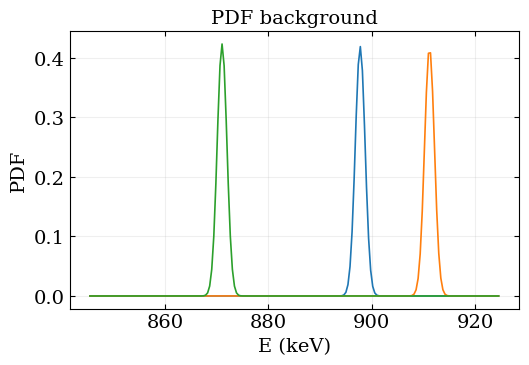

In [81]:
for i in range(len(mu_bg)):
    plt.title("PDF background")
    plt.plot(E,PDF_bg[i] )
    plt.xlabel("E (keV)")
    plt.ylabel("PDF")
    plt.grid(alpha = 0.2)
plt.plot(E,PDF_signal )

In [82]:
import pytensor.tensor as pt
import arviz as az
import multiprocessing

In [83]:
picchi_bg = ["207Tl",  "228Ac"]  # esempio: 6 picchi
num_picchi = len(picchi_bg)

In [ ]:
with pm.Model() as model:

    # --- PRIOR sulle ampiezze dei picchi di background ---
    A_bg = {}
    for name in picchi_bg:
        A_hat = results[name]["N"]          # valore dal fit curve_fit
        sigma_A = results[name]["err_N"]    # errore dal fit curve_fit

        # prior gaussiana centrata sul fit
        A_bg[name] = pm.Normal(
            f"A_{name}",
            mu=A_hat,
            sigma=sigma_A
        )

    # --- PRIOR sul segnale ---
    A_signal = pm.Uniform("A_signal", lower=0, upper=1000)

    # --- PRIOR sul background piatto ---
    Q = pm.Uniform("Q", lower=0, upper=1000)

    # --- COSTRUZIONE DEL MODELLO ---
    # Stack delle ampiezze dei picchi di background
    A_bg_array = pt.stack([A_bg[name] for name in picchi_bg])

    # Modello totale:
    #   Q = fondo piatto
    #   A_bg * PDF_bg = somma dei contributi dei picchi di background
    #   A_signal * PDF_signal = picco del segnale
    lambda_E = (
        Q
        + pt.sum(A_bg_array.reshape((num_picchi, 1)) * PDF_bg, axis=0)
        + A_signal * PDF_signal
    )

    # --- LIKELIHOOD POISSON ---
    counts_obs = pm.Poisson(
        "counts_obs",
        mu=lambda_E,
        observed=counts
    )

    # --- SAMPLING ---
    trace = pm.sample(
        100,
        tune=100,
        cores=5,
        chains=4,
        target_accept=0.9,
        return_inferencedata=True,
        progressbar=True
    )


Only 50 samples per chain. Reliable r-hat and ESS diagnostics require longer chains for accurate estimate.
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [A_207Tl, A_228Ac, A_signal, Q]


Output()

Sampling 2 chains for 50 tune and 50 draw iterations (100 + 100 draws total) took 222 seconds.
The number of samples is too small to check convergence reliably.


In [97]:
az.summary(trace, round_to=4).head()

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
A_207Tl,42.9843,2.4802,39.4856,48.0933,0.4482,0.1920,28.7405,71.6995,1.0623
A_228Ac,20.6207,2.5809,16.5463,25.8487,0.9090,0.2516,8.6537,32.4342,1.2156
A_signal,1.5254,1.2291,0.0431,3.5287,0.1380,0.0974,52.4104,36.8178,0.9929
Q,1.3785,0.0896,1.1666,1.4879,0.0093,0.0075,88.9404,56.6132,1.0184


<Figure size 600x400 with 0 Axes>

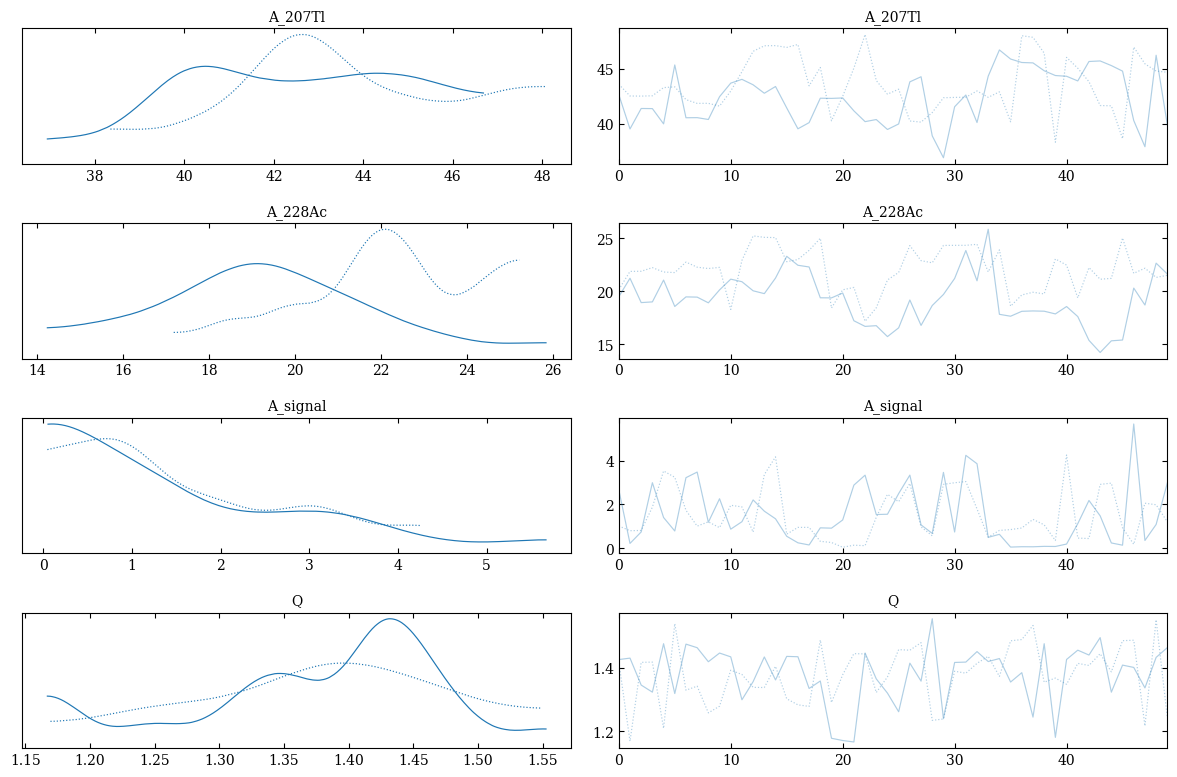

In [98]:
plt.figure(figsize = (6,4))
axes = az.plot_trace(trace)
fig = plt.gcf()
fig.tight_layout()
plt.show()

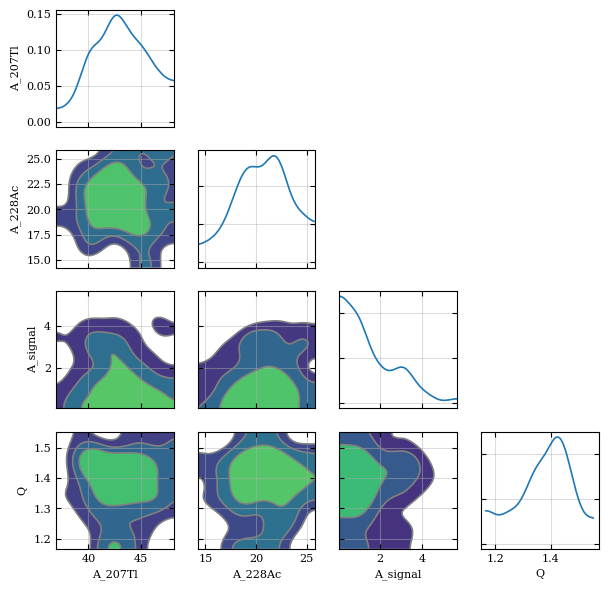

In [99]:

axes = az.plot_pair(
    trace,
    kind="kde",
    marginals=True,
    textsize=8,
    figsize=(7, 7)
)

for ax in axes.flatten():
    ax.grid(alpha = 0.45)

plt.show()

In [88]:
signal_samples = trace.posterior['A_signal'].values.flatten()
N_signal_90 = np.percentile(signal_samples, 90)

print("Upper limit on N_signal (90%):", N_signal_90)

Upper limit on N_signal (90%): 3.4289627253480575


Upper limit (68%): 1.91
Upper limit (90%): 3.43
Upper limit (95%): 3.98


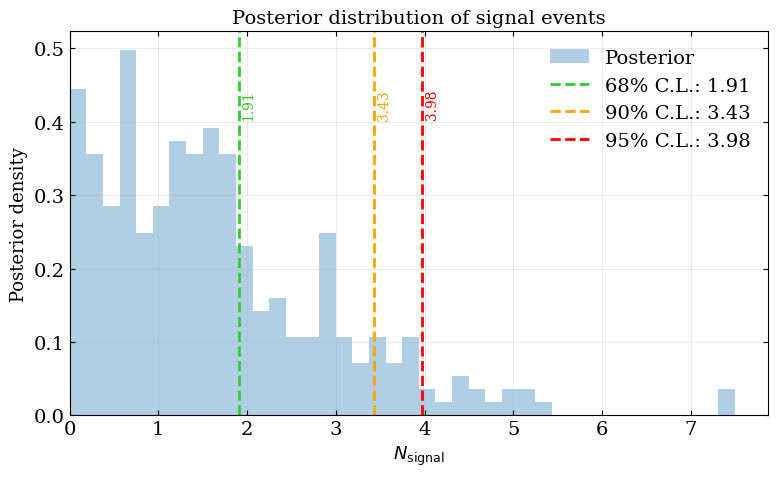

In [89]:

# Percentili
p68 = np.percentile(signal_samples, 68)
p90 = np.percentile(signal_samples, 90)
p95 = np.percentile(signal_samples, 95)

# Figura
fig, ax = plt.subplots(figsize=(8,5))

# Istogramma
ax.hist(
    signal_samples,
    bins=40,
    density=True,
    histtype='stepfilled',
    alpha=0.35,
    linewidth=1.8,
    label="Posterior"
)

# Linee percentili
limits = [
    (p68, "68% C.L.", "limegreen"),
    (p90, "90% C.L.", "orange"),
    (p95, "95% C.L.", "red"),
]

for value, label, color in limits:
    ax.axvline(
        value,
        linestyle='--',
        linewidth=2,
        color=color,
        label=f"{label}: {value:.2f}"
    )

    # testo vicino alla linea
    ax.text(
        value + 0.03,
        ax.get_ylim()[1]*0.85,
        f"{value:.2f}",
        rotation=90,
        color=color,
        va='top',
        fontsize=10
    )

# Stampa risultati
print(f"Upper limit (68%): {p68:.2f}")
print(f"Upper limit (90%): {p90:.2f}")
print(f"Upper limit (95%): {p95:.2f}")

# Stile
ax.set_xlabel(r"$N_{\mathrm{signal}}$", fontsize=13)
ax.set_ylabel("Posterior density", fontsize=13)
ax.set_title("Posterior distribution of signal events", fontsize=14)

ax.set_xlim(left=0)
ax.grid(alpha=0.25)

# legenda migliore
ax.legend(frameon=False)

plt.tight_layout()
plt.show()

In [90]:
posterior_means = {name: trace.posterior[name].mean().values for name in trace.posterior.data_vars}

print("Ampiezze medie dei picchi:")
for name, val in posterior_means.items():
    print(f"{name}: {val:.2f}")

Ampiezze medie dei picchi:
A_207Tl: 43.16
A_228Ac: 20.98
A_signal: 1.64
Q: 1.38


In [91]:
# Ricostruzione lambda_E dal trace
lambda_pred = posterior_means['Q'] * np.ones_like(E)

for i, name in enumerate(picchi_bg):
    lambda_pred += posterior_means[f"A_{name}"] * PDF_bg[i]

lambda_pred += posterior_means['A_signal'] * PDF_signal

In [92]:
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 14,
    "axes.labelsize": 14,
    "axes.titlesize": 14,
    "legend.fontsize": 14,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "figure.figsize": (5.8, 3.6),  # tipico per colonna singola
    "lines.linewidth": 1.2,
    "axes.linewidth": 0.8,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
})

In [93]:
idata = trace  # se return_inferencedata=True

idata.posterior

<xarray.Dataset> Size: 11kB
Dimensions:   (chain: 2, draw: 150)
Coordinates:
  * chain     (chain) int64 16B 0 1
  * draw      (draw) int64 1kB 0 1 2 3 4 5 6 7 ... 143 144 145 146 147 148 149
Data variables:
    A_207Tl   (chain, draw) float64 2kB 42.47 44.01 42.79 ... 40.48 45.19 47.71
    A_228Ac   (chain, draw) float64 2kB 22.1 21.5 19.31 ... 16.79 20.81 22.07
    A_signal  (chain, draw) float64 2kB 0.1372 0.958 1.591 ... 1.392 1.769
    Q         (chain, draw) float64 2kB 1.468 1.376 1.378 ... 1.342 1.264 1.414
Attributes:
    created_at:                 2026-05-11T11:59:58.403478+00:00
    arviz_version:              0.22.0
    inference_library:          pymc
    inference_library_version:  5.26.1
    sampling_time:              127.83138036727905
    tuning_steps:               150

C:\Users\rirri\AppData\Local\Temp\ipykernel_27600\477115360.py:88: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax1.set_ylim(0, 25)


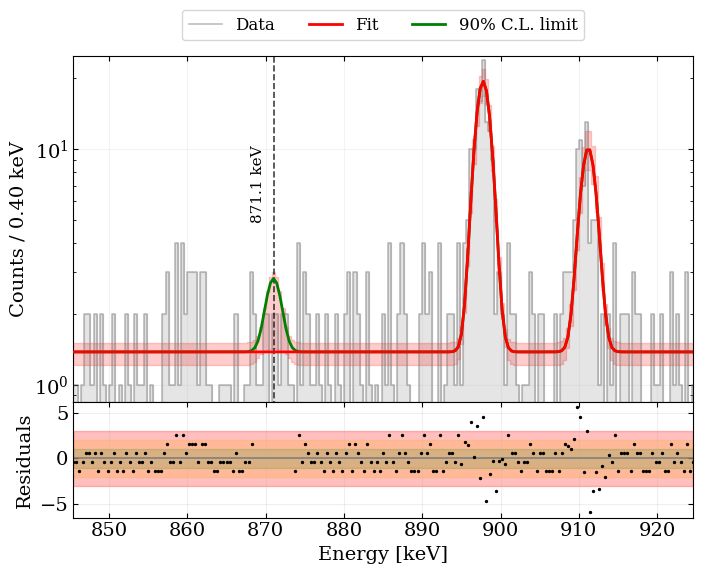

In [94]:
import numpy as np
import matplotlib.pyplot as plt

# =========================
# FIGURA CON 2 SUBPLOT
# =========================
fig, (ax1, ax2) = plt.subplots(
    2, 1,
    sharex=True,
    gridspec_kw={"height_ratios": [3, 1]},
    figsize=(8, 6)
)

# =========================
# POSTERIOR FLATTENING
# =========================
posterior = idata.posterior

Q_s = posterior["Q"].values.reshape(-1)
A_signal_s = posterior["A_signal"].values.reshape(-1)

A_bg_s = {}
for name in picchi_bg:
    A_bg_s[name] = posterior[f"A_{name}"].values.reshape(-1)

# =========================
# λ(E) PER OGNI SAMPLE
# =========================
lambda_samples = []

for i in range(len(Q_s)):
    lam = Q_s[i] * np.ones_like(E)

    for j, name in enumerate(picchi_bg):
        lam += A_bg_s[name][i] * PDF_bg[j]

    lam += A_signal_s[i] * PDF_signal
    lambda_samples.append(lam)

lambda_samples = np.array(lambda_samples)

# =========================
# RESIDUI
# =========================
window = 2.5
E0 = 871.1
mask = (E < E0 - window) | (E > E0 + window)

lambda_mean = np.mean(lambda_samples, axis=0)

residuals = counts - lambda_mean

# =========================
# BASELINE + FIT
# =========================
B_array = posterior_means['Q'] * np.ones_like(E)

lambda_pred_bkg = B_array.copy()
for i, name in enumerate(picchi_bg):
    lambda_pred_bkg += posterior_means[f"A_{name}"] * PDF_bg[i]

lambda_pred = lambda_pred_bkg + N_signal_90 * PDF_signal
lambda_low = np.percentile(lambda_samples, 5, axis=0)
lambda_high = np.percentile(lambda_samples, 95, axis=0)
# =========================
# PLOT SUPERIORE (SPETTRO)
# =========================
ax1.step(E, counts, where='mid', alpha=0.5, color='grey', label='Data')
ax1.fill_between(E, counts, color='grey', step='mid', alpha=0.2)

ax1.plot(E, lambda_pred_bkg, color='red', lw=2, zorder = 10, label='Fit')
ax1.plot(E, lambda_pred, color='green', lw=2, zorder = 5,label='90% C.L. limit')

ax1.fill_between(E, lambda_low, lambda_high,
                 color='red', alpha=0.2, step='mid')

ax1.vlines(871, 0, 30, ls='--', color='black', alpha=0.75)

ax1.annotate(
    "871.1 keV",
    xy=(871.1 - 3, 5),
    rotation=90,
    fontsize=11
)

ax1.set_yscale('log')
ax1.set_ylabel("Counts / 0.40 keV")
ax1.set_ylim(0, 25)
ax1.grid(alpha=0.15)

ax1.legend(
    loc="lower center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=3,
    fontsize=12
)

# niente ticks sopra
ax1.tick_params(axis='x', which='both', bottom=False, labelbottom=False)

# =========================
# PLOT INFERIORE (RESIDUI)
# =========================
ax2.scatter(E[mask], residuals[mask], s = 2, color='black', zorder=10)

ax2.axhspan(-3, 3, color='red', alpha=0.25)
ax2.axhspan(-2, 2, color='orange', alpha=0.2)
ax2.axhspan(-1, 1, color='green', alpha=0.15)

ax2.axhline(0, color='gray')

ax2.set_xlabel("Energy [keV]")
ax2.set_ylabel("Residuals")
ax2.grid(alpha=0.2)

plt.xlim(min(E), max(E))

# =========================
# SPAZIO ZERO TRA I PLOT
# =========================
plt.subplots_adjust(hspace=0)

plt.show()

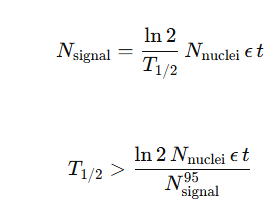

In [ ]:

# Dati campione
m_sample = 551.3        # massa ZrO2 in grammi
Mr_sample = 123.22      # massa molare ZrO2 [g/mol]
N_A = 6.022e23          # numero di Avogadro
eff_94Zr = 0.022935    # efficienza di rivelazione
i_a_94Zr = 0.1738       # abbondanza isotopica
t_live =  0.1356             # 50 giorni in anni

# Posterior del numero di eventi segnale
signal_samples = trace.posterior['A_signal'].values.flatten()

# Numero di nuclei 96Zr nel campione
N_nuclei = (m_sample * i_a_94Zr / Mr_sample) * N_A

percentile = 90

T_half_limit = (np.log(2) * N_nuclei * eff_94Zr * t_live) / np.percentile(signal_samples, percentile)
print(f"T1/2 > {T_half_limit:.2e} yrs at {percentile}%")

T1/2 > 3.03e+20 yrs at 90%


## 